In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [25]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

In [26]:
patients = pd.read_csv('../data/raw/patients.csv', parse_dates=['registration_date'])
vitals = pd.read_csv('../data/raw/vital_signs.csv', parse_dates=['timestamp'])
history = pd.read_csv('../data/raw/clinical_history.csv')
labs = pd.read_csv('../data/raw/laboratory_results.csv', parse_dates=['timestamp'])
outcomes = pd.read_csv('../data/raw/sepsis_outcomes.csv', parse_dates=['diagnosis_time'])

tables = {'patients': patients, 'vitals': vitals, 'history': history, 'labs': labs, 'outcomes': outcomes}
for name, df in tables.items():
    print(f"{name:10s} shape: {df.shape}")
    # display(df.head())

patients   shape: (5000, 5)
vitals     shape: (99737, 8)
history    shape: (12459, 6)
labs       shape: (20034, 8)
outcomes   shape: (5000, 6)


In [27]:
patients.head()

,patient_id,age,gender,medical_conditions,registration_date
0,1,66,Male,None reported,2024-12-11
1,2,42,Male,None reported,2025-08-24
2,3,74,Female,None reported,2024-07-18
3,4,77,Female,None reported,2024-08-18
4,5,25,Male,COPD,2024-04-09


In [28]:
vitals.describe().T

,count,mean,min,25%,50%,75%,max,std
observation_id,99737.0,49869.0,1.0,24935.0,49869.0,74803.0,99737.0,28791.736236
patient_id,99737.0,2504.455989,1.0,1263.0,2507.0,3759.0,5000.0,1443.230067
timestamp,99737,2025-01-04 18:19:20.888737,2024-01-01 04:26:00,2024-07-03 22:21:00,2025-01-05 06:16:00,2025-07-12 07:57:00,2025-12-30 04:43:00,NaN
heart_rate,97234.0,84.825789,41.3,74.1,81.3,91.8,149.0,15.773306
temperature,97254.0,36.964523,33.5,36.52,36.85,37.24,40.32,0.806042
oxygen_saturation,97330.0,96.39427,84.1,95.7,97.0,98.0,100.0,2.458295
respiratory_rate,97231.0,17.72458,8.0,14.9,16.8,19.4,37.8,4.230872
blood_pressure,97253.0,116.945143,55.0,108.1,118.5,127.3,166.7,14.981731


In [29]:
labs.describe().T

,count,mean,min,25%,50%,75%,max,std
lab_id,20034.0,10017.5,1.0,5009.25,10017.5,15025.75,20034.0,5783.461982
patient_id,20034.0,2498.602775,1.0,1252.0,2494.0,3744.75,5000.0,1445.073408
timestamp,20034,2025-01-06 05:54:41.623240,2024-01-01 21:24:00,2024-07-06 15:40:30,2025-01-08 20:47:00,2025-07-12 18:04:00,2025-12-30 05:27:00,NaN
white_cell_count,19415.0,8.664519,1.0,6.5,7.9,9.68,27.44,3.691498
crp,19467.0,29.36903,0.5,4.2,7.8,14.7,200.1,45.187629
lactate,19418.0,1.564202,0.3,0.87,1.11,1.54,6.51,1.147333
creatinine,19457.0,1.062036,0.3,0.8,0.98,1.23,2.8,0.389485
platelet_count,19433.0,243.923378,17.0,211.0,248.0,281.0,418.0,52.806299


In [30]:
# numbet of patients with sepsis
print('Sepsis Prevalence:', outcomes['sepsis_event'].mean().round(3))
outcomes['sepsis_event'].value_counts()

Sepsis Prevalence: 0.46


sepsis_event
False    2700
True     2300
Name: count, dtype: int64

## Data Quality Assessment

In [31]:
# check for missing values in each table
def missing_report(df, name):
    missing = df.isna().mean().mul(100).round(2)
    missing = missing[missing > 0]
    if len(missing):
        print(f"---Columns with missing values in {name}---")
        print(missing.to_string())
        
for name, df in tables.items():
    missing_report(df, name)

---Columns with missing values in vitals---
heart_rate           2.51
temperature          2.49
oxygen_saturation    2.41
respiratory_rate     2.51
blood_pressure       2.49
---Columns with missing values in labs---
white_cell_count    3.09
crp                 2.83
lactate             3.07
creatinine          2.88
platelet_count      3.00
---Columns with missing values in outcomes---
diagnosis_time    54.0


In [32]:
# check for duplicate rows in each table
for name, df in tables.items():
    print(name, 'duplicate rows', df.duplicated().sum())

patients duplicate rows 0
vitals duplicate rows 0
history duplicate rows 0
labs duplicate rows 0
outcomes duplicate rows 0


In [33]:

# check for negative values in numeric columns (e.g. vitals/labs shouldn't be negative)
def negative_report(df, name):
    numeric_cols = df.select_dtypes(include='number').columns
    neg_counts = (df[numeric_cols] < 0).sum()
    neg_counts = neg_counts[neg_counts > 0]
    if len(neg_counts):
        print(f"---Columns with negative values in {name}---")
        print(neg_counts.to_string())

for name, df in tables.items():
    negative_report(df, name)

In [34]:
# Referential Integrity Checks
valid_patients_id = set(patients['patient_id'])
for name, df in [('vitals', vitals), ('history', history), ('labs', labs), ('outcomes', outcomes)]:
    orphans = (~df['patient_id'].isin(valid_patients_id)).sum()
    print(name, 'orphaned patient_id rows:', orphans)

vitals orphaned patient_id rows: 0
history orphaned patient_id rows: 0
labs orphaned patient_id rows: 0
outcomes orphaned patient_id rows: 0


In [35]:
# Check for out of range values in vitals

ranges = {
    'heart_rate': (30, 200), 
    'temperature': (32, 43), 
    'oxygen_saturation': (50, 100), 
    'respiratory_rate': (5, 60), 
    'blood_pressure': (40, 220)
}

for col, (min_val, max_val) in ranges.items():
    bad = ((vitals[col] < min_val) | (vitals[col] > max_val)).sum()
    print(f"{col:20s} out of range values: {bad}")

heart_rate           out of range values: 0
temperature          out of range values: 0
oxygen_saturation    out of range values: 0
respiratory_rate     out of range values: 0
blood_pressure       out of range values: 0


In [36]:
# Check for out of range values in labs
vital_cols = [
    'heart_rate', 
    'temperature', 
    'oxygen_saturation', 
    'respiratory_rate', 
    'blood_pressure'
]

labs_cols = [
    'white_cell_count', 
    'crp',
    'lactate', 
    'creatinine', 
    'platelet_count'
]

# First: forward-fill within each patient
vitals[vital_cols] = (
    vitals.groupby('patient_id')[vital_cols]
          .transform(lambda s: s.ffill())
)
# Then: fill any remaining NaN with that same patient's median
vitals[vital_cols] = (
    vitals.groupby('patient_id')[vital_cols]
          .transform(lambda s: s.fillna(s.median()))
)

# Same thing for labs
labs[labs_cols] = (
    labs.groupby('patient_id')[labs_cols]
        .transform(lambda s: s.ffill())
)

labs[labs_cols] = (
    labs.groupby('patient_id')[labs_cols]
        .transform(lambda s: s.fillna(s.median()))
)

print("Remaining missing values -> vitals:", vitals[vital_cols].isna().sum().sum(), "& labs:", labs[labs_cols].isna().sum().sum())

Remaining missing values -> vitals: 0 & labs: 20


In [37]:
labs.columns

Index(['lab_id', 'patient_id', 'timestamp', 'white_cell_count', 'crp',
       'lactate', 'creatinine', 'platelet_count'],
      dtype='str')

In [38]:
patients.to_csv('../data/processed/patients_clean.csv', index=False)
vitals.to_csv('../data/processed/vital_signs_clean.csv', index=False)
history.to_csv('../data/processed/clinical_history_clean.csv', index=False)
labs.to_csv('../data/processed/laboratory_results_clean.csv', index=False)
outcomes.to_csv('../data/processed/sepsis_outcomes_clean.csv', index=False)


## EDA

### Patient Demographics

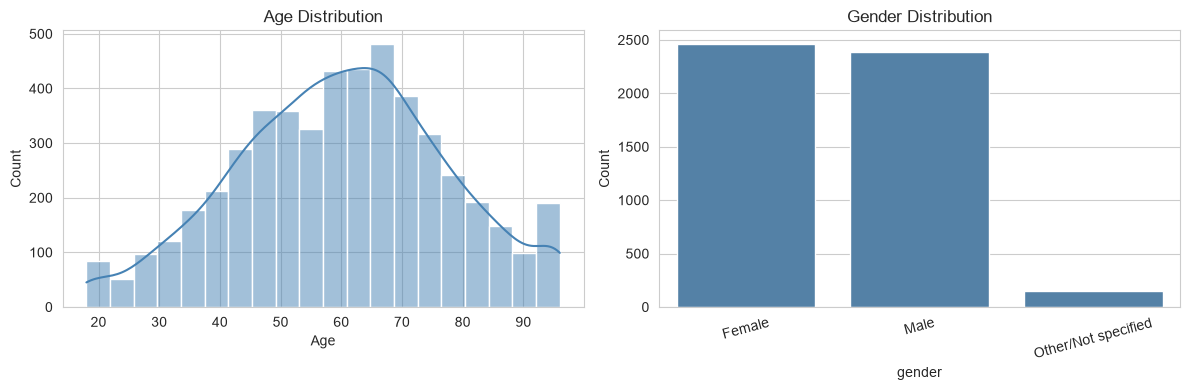

count    5000.0
mean       60.0
std        17.4
min        18.0
25%        48.0
50%        60.0
75%        72.0
max        96.0
Name: age, dtype: float64


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(patients['age'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

gender_counts = patients['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1], color='steelblue')
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(patients['age'].describe().round(1))

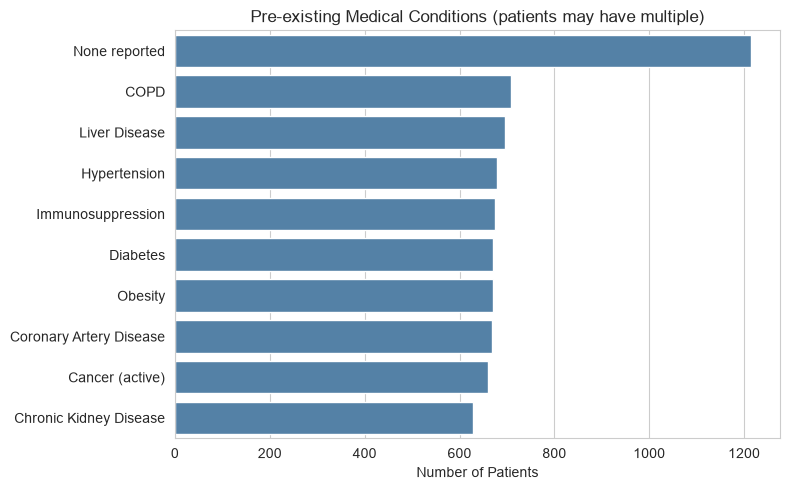

Patients with no documented conditions: 0 (0.0%)


In [40]:
# Pre-existing medical conditions are stored as comma-separated strings - explode into individual conditions
conditions = patients['medical_conditions'].dropna().str.split(', ').explode()
condition_counts = conditions.value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=condition_counts.values, y=condition_counts.index, color='steelblue')
plt.title('Pre-existing Medical Conditions (patients may have multiple)')
plt.xlabel('Number of Patients')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(f"Patients with no documented conditions: {patients['medical_conditions'].isna().sum()} ({patients['medical_conditions'].isna().mean():.1%})")

### Sepsis Outcome Overview

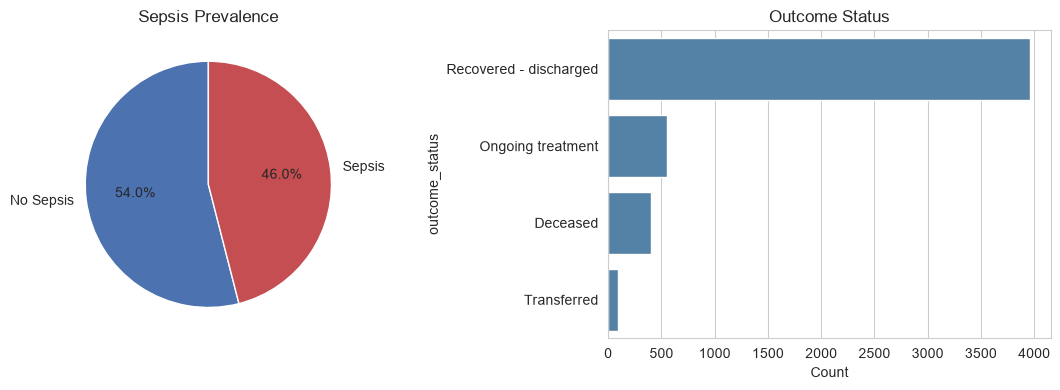

Hospitalisation required among sepsis cases: 93.8%
Hospitalisation required among non-sepsis cases: 18.4%


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sepsis_counts = outcomes['sepsis_event'].value_counts()
axes[0].pie(sepsis_counts, labels=['No Sepsis', 'Sepsis'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[0].set_title('Sepsis Prevalence')

status_counts = outcomes['outcome_status'].value_counts()
sns.barplot(x=status_counts.values, y=status_counts.index, color='steelblue', ax=axes[1])
axes[1].set_title('Outcome Status')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Hospitalisation required among sepsis cases:',
      f"{outcomes.loc[outcomes['sepsis_event'], 'hospitalisation_required'].mean():.1%}")
print('Hospitalisation required among non-sepsis cases:',
      f"{outcomes.loc[~outcomes['sepsis_event'], 'hospitalisation_required'].mean():.1%}")

### Vitals & Labs by Sepsis Status
Vitals and labs are repeated measurements per patient, so we aggregate to one row per patient (mean and max) before comparing against the outcome.

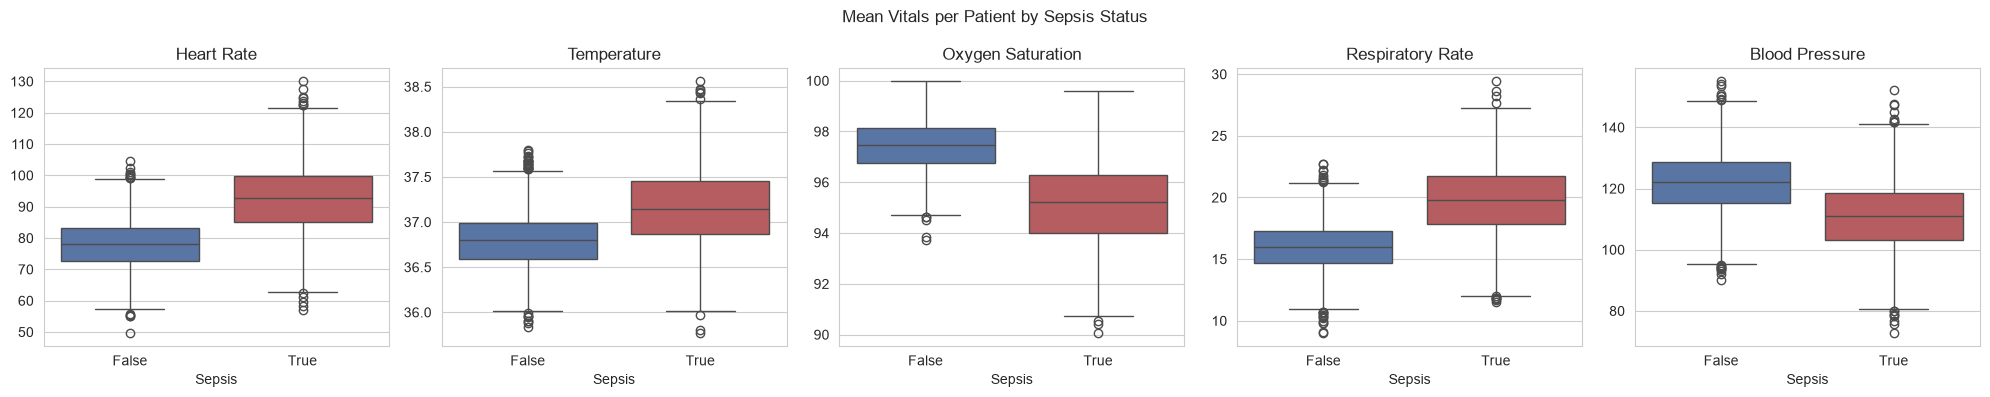

In [42]:
# Aggregate vitals to patient level (mean + max capture both baseline and peak abnormality)
vitals_agg = vitals.groupby('patient_id')[vital_cols].agg(['mean', 'max'])
vitals_agg.columns = ['_'.join(c) for c in vitals_agg.columns]
vitals_agg = vitals_agg.reset_index().merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, vital_cols):
    sns.boxplot(data=vitals_agg, x='sepsis_event', y=f'{col}_mean', ax=ax,
                hue='sepsis_event', palette=['#4C72B0', '#C44E52'], legend=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Sepsis')
    ax.set_ylabel('')

plt.suptitle('Mean Vitals per Patient by Sepsis Status')
plt.tight_layout()
plt.show()

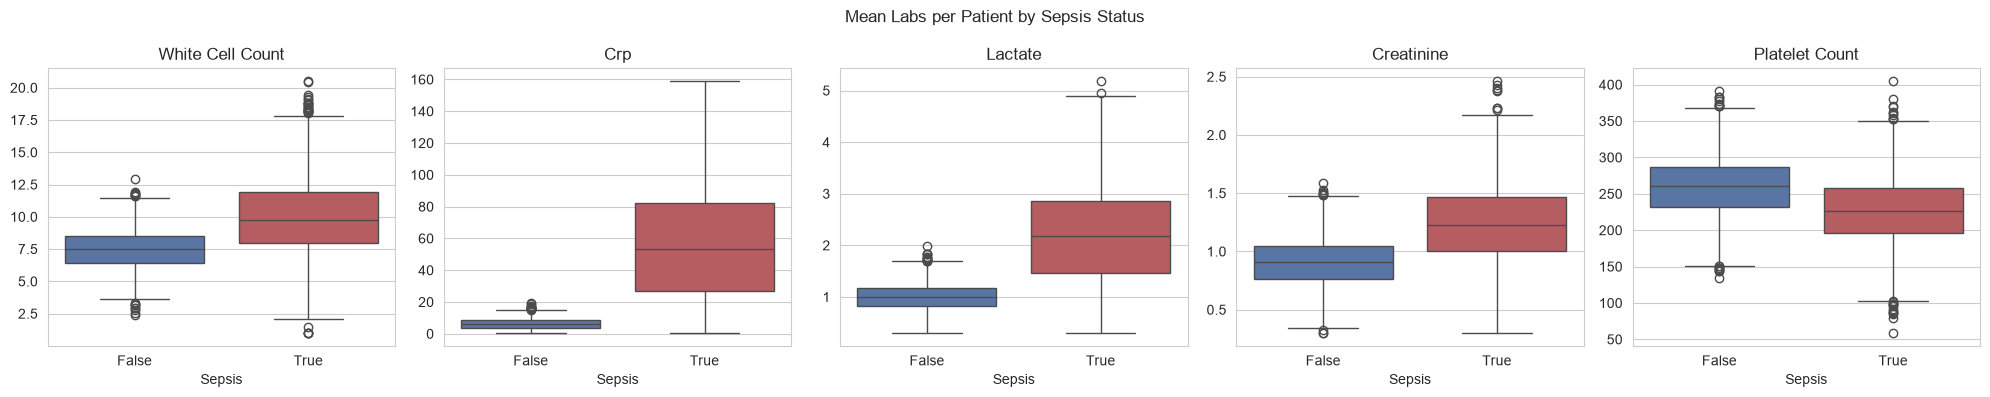

In [43]:
# Aggregate labs to patient level the same way
labs_agg = labs.groupby('patient_id')[labs_cols].agg(['mean', 'max'])
labs_agg.columns = ['_'.join(c) for c in labs_agg.columns]
labs_agg = labs_agg.reset_index().merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, labs_cols):
    sns.boxplot(data=labs_agg, x='sepsis_event', y=f'{col}_mean', ax=ax,
                hue='sepsis_event', palette=['#4C72B0', '#C44E52'], legend=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Sepsis')
    ax.set_ylabel('')

plt.suptitle('Mean Labs per Patient by Sepsis Status')
plt.tight_layout()
plt.show()

### Correlations Among Vitals & Labs

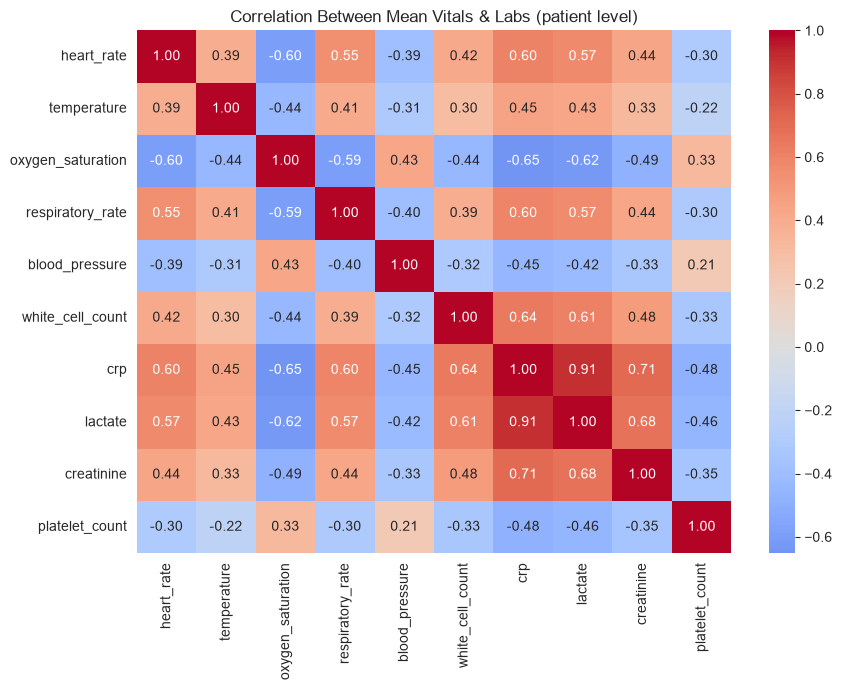

In [44]:
patient_features = vitals_agg.merge(labs_agg, on=['patient_id', 'sepsis_event'], how='outer')
mean_cols = [c for c in patient_features.columns if c.endswith('_mean')]

plt.figure(figsize=(9, 7))
corr = patient_features[mean_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[c.replace('_mean', '') for c in mean_cols],
            yticklabels=[c.replace('_mean', '') for c in mean_cols])
plt.title('Correlation Between Mean Vitals & Labs (patient level)')
plt.tight_layout()
plt.show()

### Age & Clinical History vs Sepsis

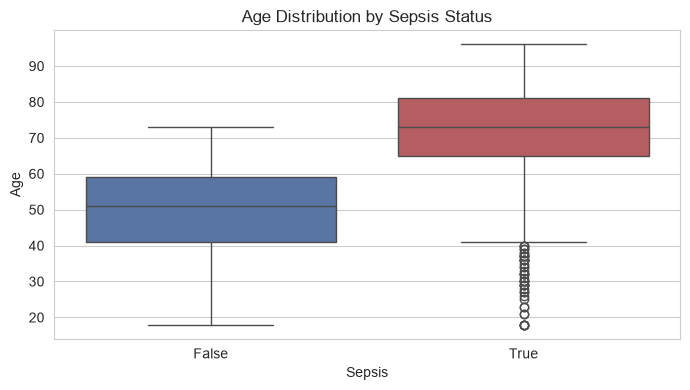

              mean   50%   std
sepsis_event                  
False         49.3  51.0  12.5
True          72.7  73.0  13.5


In [45]:
age_outcome = patients.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')

plt.figure(figsize=(7, 4))
sns.boxplot(data=age_outcome, x='sepsis_event', y='age',
            hue='sepsis_event', palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Age Distribution by Sepsis Status')
plt.xlabel('Sepsis')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

print(age_outcome.groupby('sepsis_event')['age'].describe()[['mean', '50%', 'std']].round(1))

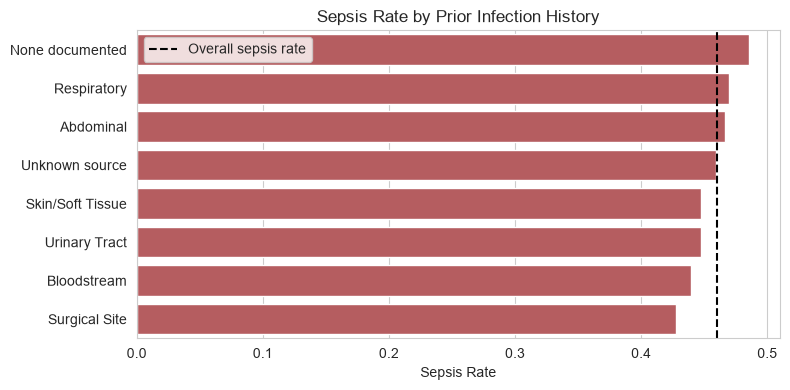

In [46]:
# Infection source history vs sepsis rate (row-level, patients can have multiple history entries)
history_outcome = history.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')
sepsis_rate_by_infection = (history_outcome.groupby('infection_history')['sepsis_event'].mean().sort_values(ascending=False))

plt.figure(figsize=(8, 4))
sns.barplot(x=sepsis_rate_by_infection.values, y=sepsis_rate_by_infection.index, color='#C44E52')
plt.axvline(outcomes['sepsis_event'].mean(), color='black', linestyle='--', label='Overall sepsis rate')
plt.title('Sepsis Rate by Prior Infection History')
plt.xlabel('Sepsis Rate')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

### Key Takeaways
- **Class imbalance**: Sepsis prevalence is ~12% (72/600 patients) — models will need to account for this (e.g. class weighting, resampling, or threshold tuning).
- **Vitals & labs separate sepsis cases**: patients with sepsis tend to show higher heart rate, respiratory rate, lactate, CRP and white cell count, and lower blood pressure and oxygen saturation — consistent with clinical expectations (SIRS/sepsis criteria).
- **Correlated features**: several vitals/labs are moderately correlated (e.g. heart rate and respiratory rate), which is worth keeping in mind for feature selection/regularisation.
- **Data completeness**: `diagnosis_time` is missing for ~88% of patients — expected, since it's only recorded for the ~12% who developed sepsis, not a data quality issue.
- **Infection history and age** show some association with sepsis risk and could be useful engineered features alongside the time-series vitals/labs.